#### Chocolate Sales Data Analysis using Python

In [117]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Chocolate Sales Data Analysis
## 1. Import Libraries

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline

##LOAD ALL CSV DATA FROM LOCAL 


In [119]:

customers = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\chcolate DB\customers.csv")
products = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\chcolate DB\products.csv")
stores = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\chcolate DB\stores.csv")
sales = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\chcolate DB\sales.csv")



####CHECK ALL DATA 

In [120]:
customers.head()


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,21-05-2025
1,C000002,47,Male,0,26-12-2021
2,C000003,58,Female,1,13-09-2022
3,C000004,25,Female,0,27-02-2025
4,C000005,43,Male,0,31-08-2023


In [121]:
products.head()


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [122]:
stores.head()


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


In [123]:
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,07-01-2023,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,22-10-2023,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,07-05-2023,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,23-06-2024,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,24-09-2024,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [124]:
###DATASET INFORMATION
customers.info()
products.info()
stores.info()
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     50000 non-null  str  
 1   age             50000 non-null  int64
 2   gender          50000 non-null  str  
 3   loyalty_member  50000 non-null  int64
 4   join_date       50000 non-null  str  
dtypes: int64(2), str(3)
memory usage: 1.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     200 non-null    str  
 1   product_name   200 non-null    str  
 2   brand          200 non-null    str  
 3   category       200 non-null    str  
 4   cocoa_percent  200 non-null    int64
 5   weight_g       200 non-null    int64
dtypes: int64(2), str(4)
memory usage: 9.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5

In [125]:
###data type conert to date format joi_date from customers and from sales order_date
customers["join_date"] = pd.to_datetime(
    customers["join_date"],
    format="%d-%m-%Y"
)

sales["order_date"] = pd.to_datetime(
    sales["order_date"],
    format="%d-%m-%Y"
)

In [126]:
##Check:
customers.info()

sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     50000 non-null  str           
 1   age             50000 non-null  int64         
 2   gender          50000 non-null  str           
 3   loyalty_member  50000 non-null  int64         
 4   join_date       50000 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 1.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   order_id     990236 non-null  str           
 1   order_date   990236 non-null  datetime64[us]
 2   product_id   990236 non-null  str           
 3   store_id     990236 non-null  str           
 4   customer_id  990236 non-null  str           
 5   quantity     990236

In [127]:
##Convert Loyalty Member boolean
customers["loyalty_member"] = customers["loyalty_member"].astype(bool)

In [128]:
##check
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     50000 non-null  str           
 1   age             50000 non-null  int64         
 2   gender          50000 non-null  str           
 3   loyalty_member  50000 non-null  bool          
 4   join_date       50000 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](1), int64(1), str(2)
memory usage: 1.6 MB


In [129]:
##Join Tables
sales_customer = pd.merge(sales, customers, on="customer_id")

sales_customer_product = pd.merge(sales_customer, products, on="product_id")

final_df = pd.merge(sales_customer_product, stores, on="store_id")

In [130]:
##check rows and columns
final_df.shape

(990236, 24)

In [131]:
##check data
final_df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,join_date,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2021-11-17,Praline Chocolate 70%,Hershey,White,70,200,Chocolate Store 93,Sydney,UK,Airport
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-07-03,Dark Chocolate 60%,Lindt,Praline,60,50,Chocolate Store 65,New York,Australia,Retail
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-10-09,Milk Chocolate 90%,Hershey,Milk,90,50,Chocolate Store 78,London,UK,Airport
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,2023-05-30,Dark Chocolate 60%,Godiva,Praline,60,50,Chocolate Store 88,Toronto,USA,Retail
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,2021-08-20,Truffle Chocolate 90%,Hershey,Truffle,90,120,Chocolate Store 54,London,Canada,Online


In [132]:
final_df.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit',
       'age', 'gender', 'loyalty_member', 'join_date', 'product_name', 'brand',
       'category', 'cocoa_percent', 'weight_g', 'store_name', 'city',
       'country', 'store_type'],
      dtype='str')

In [133]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        990236 non-null  str           
 1   order_date      990236 non-null  datetime64[us]
 2   product_id      990236 non-null  str           
 3   store_id        990236 non-null  str           
 4   customer_id     990236 non-null  str           
 5   quantity        990236 non-null  int64         
 6   unit_price      990236 non-null  float64       
 7   discount        990236 non-null  float64       
 8   revenue         990236 non-null  float64       
 9   cost            990236 non-null  float64       
 10  profit          990236 non-null  float64       
 11  age             990236 non-null  int64         
 12  gender          990236 non-null  str           
 13  loyalty_member  990236 non-null  bool          
 14  join_date       990236 non-null  datetime64[us]

In [134]:
# Join Validation
# --------------------------
# Total Rows    : 990236
# Total Columns : 24
# Missing Values: 0
# Date Columns  : Converted to datetime
# Loyalty Member: Converted to Boolean
# Join Status   : Successful

###BUSINESS ANALYSIS

In [135]:
### Total Revenue in Million
round(final_df["revenue"].sum() / 1000000, 2)

np.float64(25.24)

In [136]:
##Total Profit in million
round(final_df["profit"].sum() / 1000000,2)

np.float64(10.1)

In [137]:
##Total Orders
final_df["order_id"].count()

np.int64(990236)

In [138]:
##Total Quantity Sold in million
round(final_df["quantity"].sum() / 1000000,2)

np.float64(2.97)

In [139]:
##Average Order Value
round(final_df["revenue"].mean(),2)

np.float64(25.49)

In [140]:
##Top 10 Products by Revenue
final_df.groupby("product_name")["revenue"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

product_name
Dark Chocolate 50%       1775041.34
Truffle Chocolate 80%    1643258.83
Milk Chocolate 70%       1384758.27
Praline Chocolate 50%    1382597.04
Dark Chocolate 60%       1272649.97
White Chocolate 50%      1265949.75
White Chocolate 90%      1137968.57
White Chocolate 80%      1133285.39
Truffle Chocolate 90%    1132883.80
Praline Chocolate 70%    1127404.94
Name: revenue, dtype: float64

In [141]:
##Top 10 Products by Profit
final_df.groupby("product_name")["profit"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

product_name
Dark Chocolate 50%       709742.67
Truffle Chocolate 80%    656761.72
Milk Chocolate 70%       553576.55
Praline Chocolate 50%    553128.09
Dark Chocolate 60%       508956.58
White Chocolate 50%      506724.07
White Chocolate 90%      455226.06
White Chocolate 80%      453805.19
Truffle Chocolate 90%    453042.38
Praline Chocolate 70%    451013.87
Name: profit, dtype: float64

In [142]:
##Revenue by Category
final_df.groupby("category")["revenue"] \
.sum() \
.sort_values(ascending=False)

category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64

In [143]:
##Revenue by Country
final_df.groupby("country")["revenue"] \
.sum() \
.sort_values(ascending=False)

country
Canada       5036623.01
UK           4777585.16
USA          4298447.49
France       4296611.25
Australia    3798165.48
Germany      3031215.83
Name: revenue, dtype: float64

In [144]:
##Revenue by City
final_df.groupby("city")["revenue"] \
.sum() \
.sort_values(ascending=False)

city
Toronto      4548214.81
London       4023252.27
Paris        4010580.34
New York     3804074.96
Sydney       3290556.29
Melbourne    3028464.16
Berlin       2533505.39
Name: revenue, dtype: float64

In [145]:
##Loyalty Members
final_df.groupby("loyalty_member")[["revenue","profit"]].sum()

,revenue,profit
loyalty_member,,
False,12590612.84,5036745.46
True,12648035.38,5058896.45


In [146]:
##Gender Analysis revenue in million
round(final_df.groupby("gender")["revenue"].sum() / 1000000,2)

gender
Female    12.51
Male      12.73
Name: revenue, dtype: float64

In [147]:
##Monthly Revenue Trend
final_df.groupby(final_df["order_date"].dt.to_period("M"))["revenue"].sum()

order_date
2023-01    1084177.53
2023-02     959873.03
2023-03    1074291.06
2023-04    1028124.89
2023-05    1073192.48
2023-06    1036185.37
2023-07    1072872.61
2023-08    1077255.84
2023-09    1046142.37
2023-10    1061624.49
2023-11    1027864.47
2023-12    1070443.26
2024-01    1073356.81
2024-02    1000338.38
2024-03    1072861.24
2024-04    1033262.75
2024-05    1068451.35
2024-06    1027879.53
2024-07    1075673.28
2024-08    1072169.36
2024-09    1041597.95
2024-10    1065170.57
2024-11    1029430.21
2024-12    1066409.39
Freq: M, Name: revenue, dtype: float64

In [148]:
##Monthly Profit Trend
final_df.groupby(final_df["order_date"].dt.to_period("M"))["profit"].sum()

order_date
2023-01    433841.86
2023-02    383611.51
2023-03    429658.78
2023-04    411732.24
2023-05    429400.40
2023-06    414217.32
2023-07    428788.40
2023-08    431245.37
2023-09    417753.32
2023-10    424664.79
2023-11    411419.47
2023-12    428087.21
2024-01    428914.02
2024-02    400035.36
2024-03    429386.93
2024-04    413434.60
2024-05    427362.18
2024-06    411843.46
2024-07    430083.87
2024-08    429241.45
2024-09    416789.07
2024-10    426300.15
2024-11    411713.95
2024-12    426116.20
Freq: M, Name: profit, dtype: float64

VISUALIZATION  PART

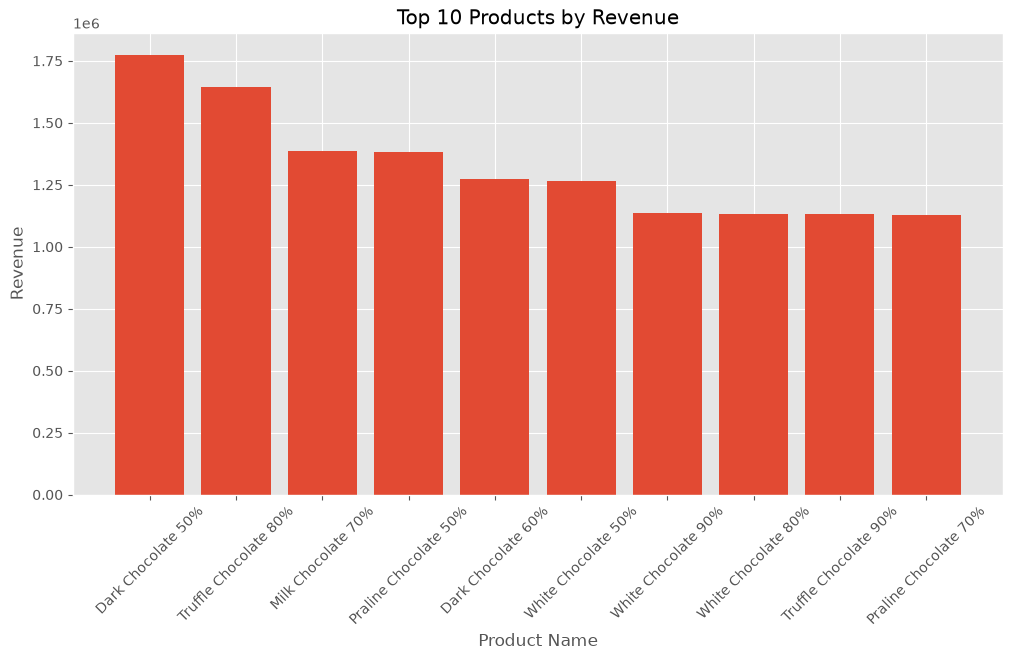

In [149]:
##Top 10 Products by Revenue
top_products = final_df.groupby("product_name")["revenue"].sum() \
.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_products.index, top_products.values)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

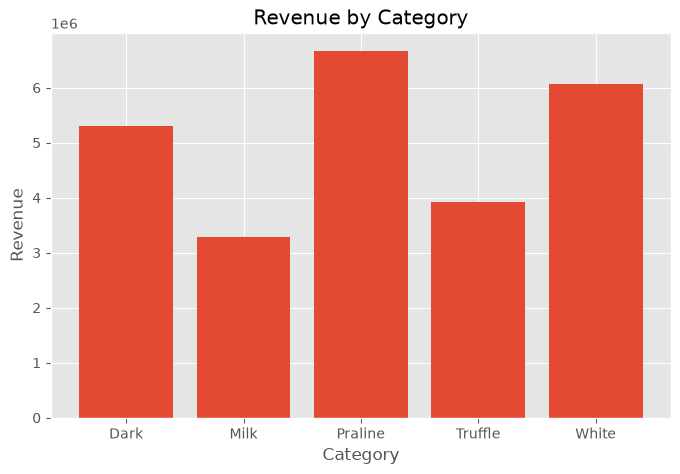

In [150]:
##Revenue by Category 
category = final_df.groupby("category")["revenue"].sum()

plt.figure(figsize=(8,5))

plt.bar(category.index, category.values)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

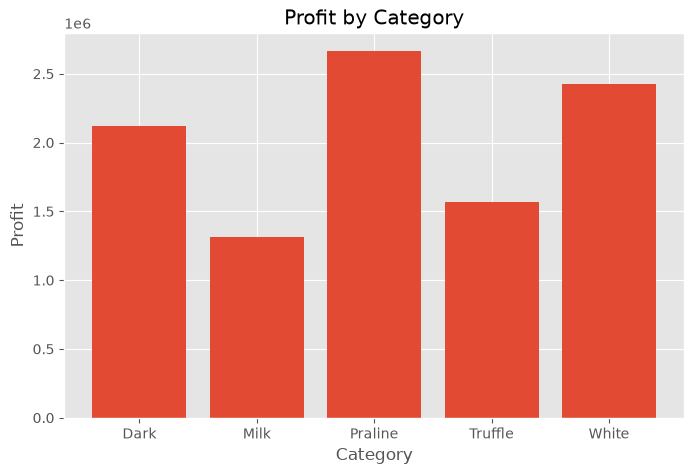

In [151]:
##Profit by Category 
profit = final_df.groupby("category")["profit"].sum()

plt.figure(figsize=(8,5))

plt.bar(profit.index, profit.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

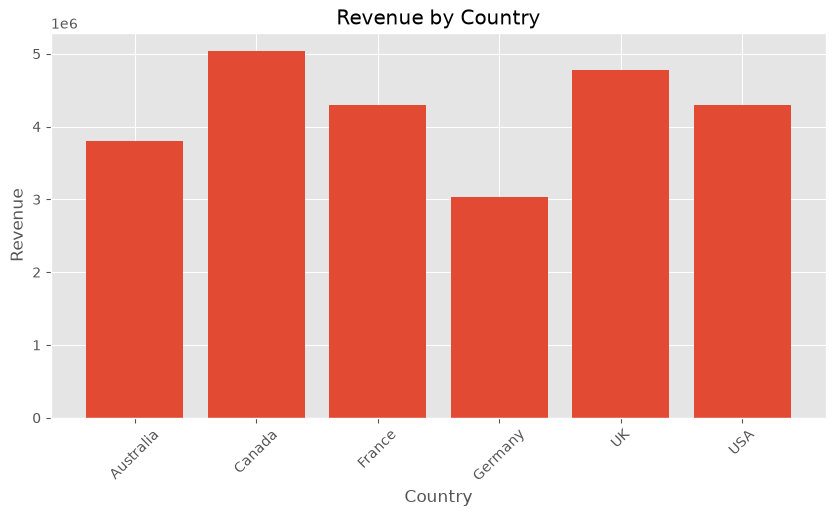

In [152]:
##Revenue by Country 
country = final_df.groupby("country")["revenue"].sum()

plt.figure(figsize=(10,5))

plt.bar(country.index, country.values)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

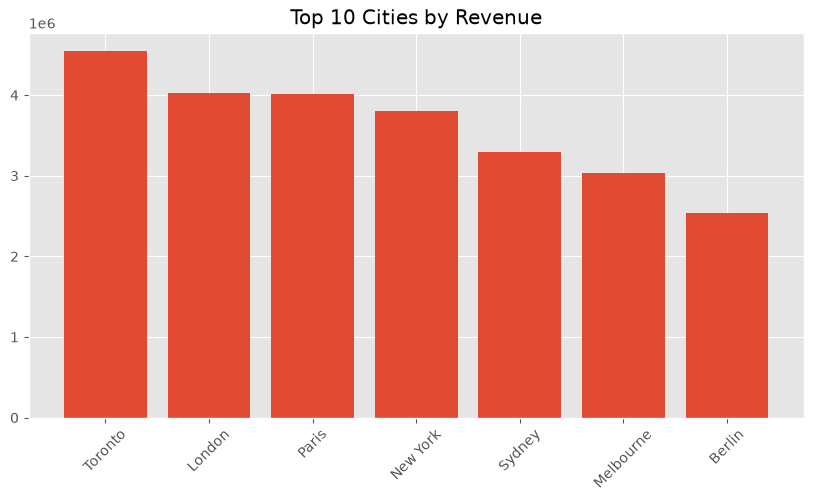

In [153]:
##Top 10 Cities 
city = final_df.groupby("city")["revenue"].sum() \
.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(city.index, city.values)

plt.title("Top 10 Cities by Revenue")

plt.xticks(rotation=45)

plt.show()

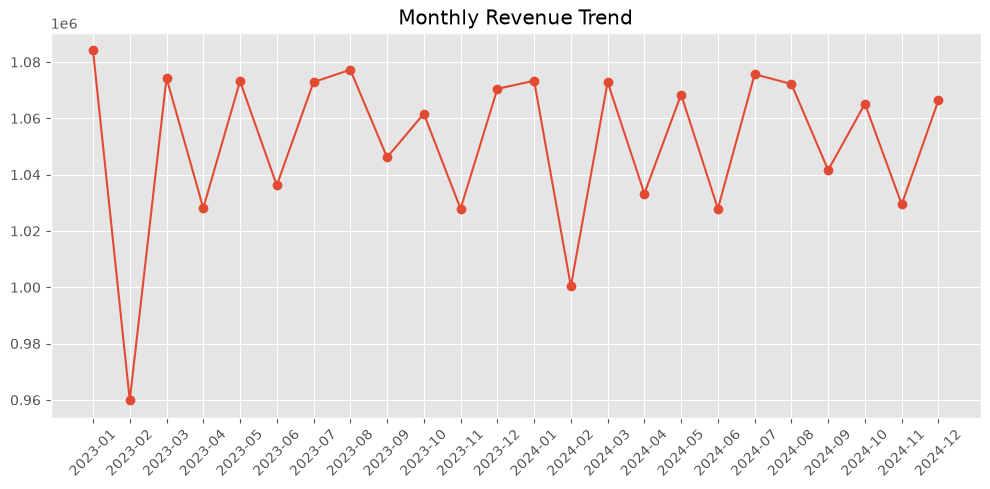

In [154]:
##Monthly Revenue Trend (Line Chart)
monthly = final_df.groupby(final_df["order_date"].dt.to_period("M"))["revenue"].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly.index.astype(str), monthly.values, marker="o")

plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)

plt.show()

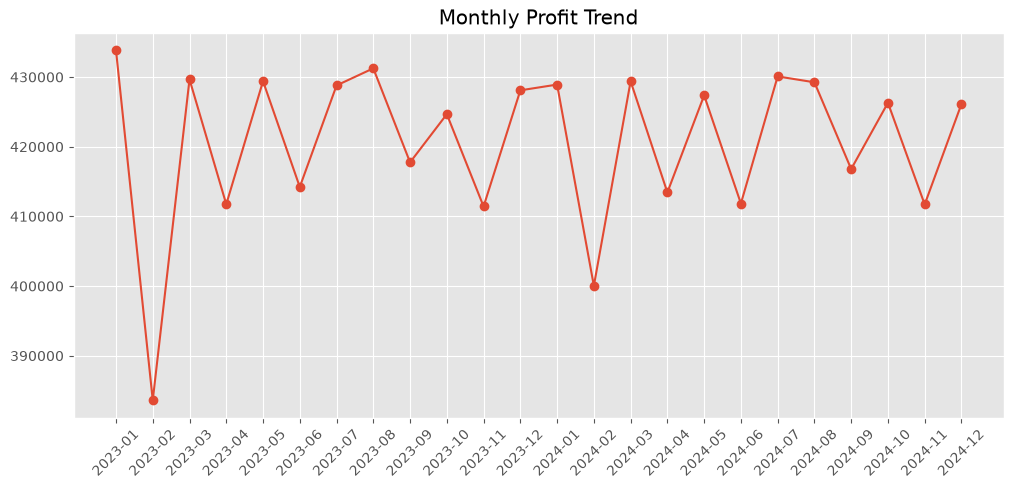

In [155]:
##Monthly Profit Trend (Line Chart)
monthly_profit = final_df.groupby(final_df["order_date"].dt.to_period("M"))["profit"].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_profit.index.astype(str), monthly_profit.values, marker="o")

plt.title("Monthly Profit Trend")

plt.xticks(rotation=45)

plt.show()

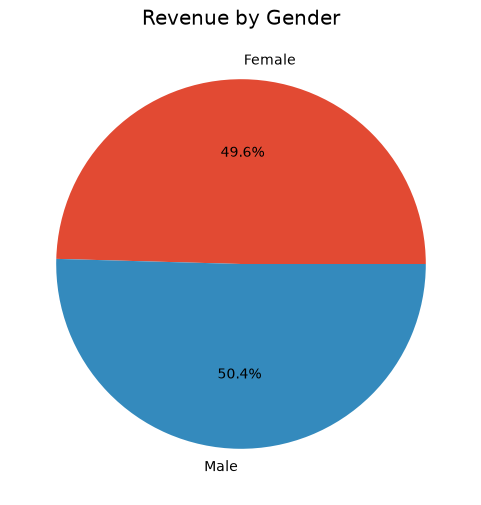

In [156]:
##Revenue by Gender (Pie Chart)
gender = final_df.groupby("gender")["revenue"].sum()

plt.figure(figsize=(6,6))

plt.pie(gender.values,
        labels=gender.index,
        autopct="%1.1f%%")

plt.title("Revenue by Gender")

plt.show()

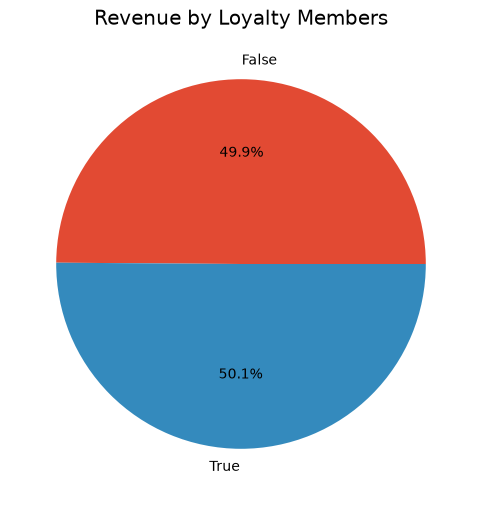

In [157]:
##Revenue by Loyalty Members (Pie Chart)
loyal = final_df.groupby("loyalty_member")["revenue"].sum()

plt.figure(figsize=(6,6))

plt.pie(loyal.values,
        labels=loyal.index,
        autopct="%1.1f%%")

plt.title("Revenue by Loyalty Members")

plt.show()

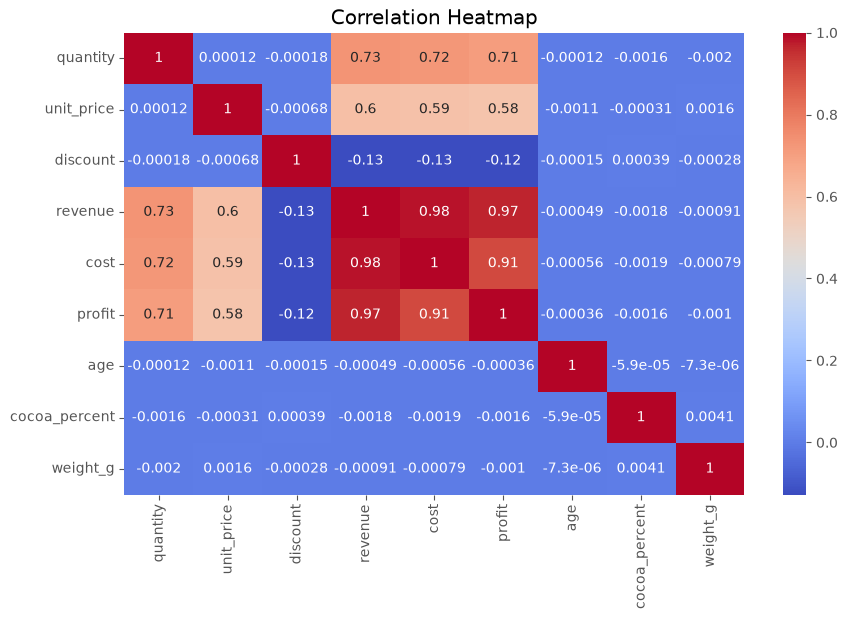

In [158]:
##Correlation Heatmap (Seaborn)
numeric = final_df.select_dtypes(include="number")

plt.figure(figsize=(10,6))

sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

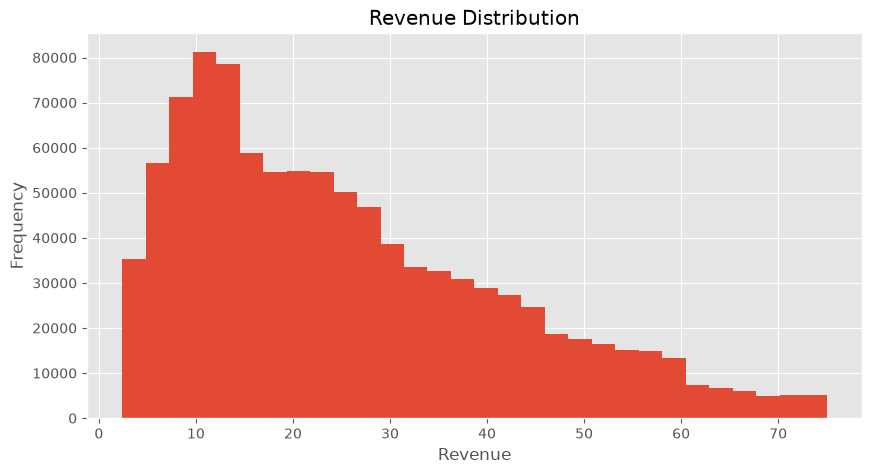

In [159]:
##Revenue Distribution (Histogram)
plt.figure(figsize=(10,5))

plt.hist(final_df["revenue"], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

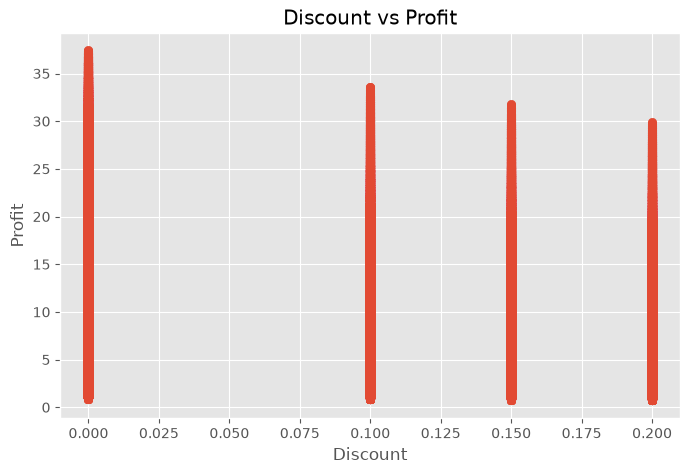

In [160]:
##Discount vs Profit (Scatter Plot)
plt.figure(figsize=(8,5))

plt.scatter(final_df["discount"],
            final_df["profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

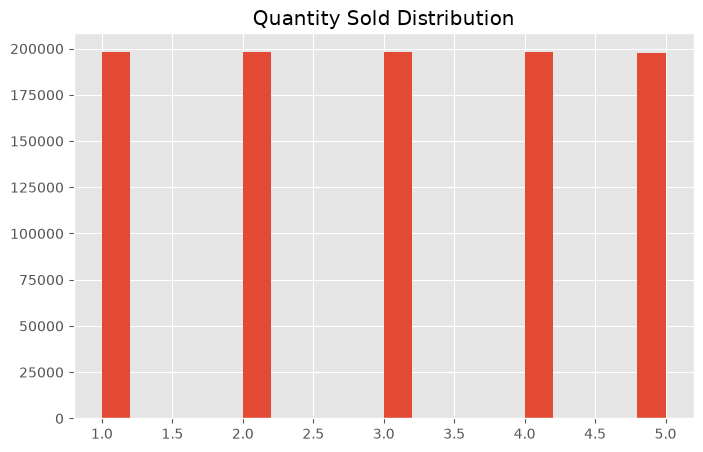

In [162]:
##Quantity Sold Distribution
plt.figure(figsize=(8,5))

plt.hist(final_df["quantity"], bins=20)

plt.title("Quantity Sold Distribution")

plt.show()

# Key Insights

• The dataset contains 990,236 sales transactions with no missing values after SQL data cleaning and table merging.

• The business generated a total revenue of 25.24 Million and a total profit of 10.10 Million from 990,236 orders.

• A total of 2,970,470 units were sold, indicating strong customer demand.

• Dark Chocolate 50% was the highest revenue-generating and best-selling product, followed by Truffle Chocolate 80%.

• Praline was the top-performing product category in terms of both revenue and profit.

• Canada generated the highest revenue among all countries, while Toronto was the highest revenue-generating city.

• Loyalty members generated slightly higher revenue and profit than non-loyal customers, showing the effectiveness of the loyalty program.

• Customers above 50 years contributed the highest revenue, making them the most valuable customer segment.

• Monthly revenue and profit remained stable across 2023 and 2024, with February showing comparatively lower performance.

• The average order value was 25.49, indicating consistent customer spending.

• Discount analysis showed a consistent pricing strategy, with average discounts remaining around 5.6%.

• Correlation analysis indicated positive relationships between quantity, revenue, cost, and profit, providing useful business insights.

# Conclusion
This project demonstrates a complete end-to-end data analysis workflow using Python.

The cleaned datasets were imported, validated, and merged using Pandas. Exploratory Data Analysis (EDA) was performed to evaluate product performance, customer behavior, sales trends, category performance, and regional revenue. Visualizations created with Matplotlib and Seaborn helped communicate business insights effectively.

The analysis identified top-performing products, profitable categories, valuable customer segments, and seasona